# Flood & Flash Flood Prediction in Malaysia Using Machine Learning
**Data Source:** NASA POWER (MERRA-2 Satellite)  
**Cities:** Kota Bharu, Kuantan, Johor Bahru, Kuala Lumpur, Shah Alam, Melaka, Kuching, Kota Kinabalu  
**Period:** January 2010 – March 2026  
**Models:** Decision Tree, Random Forest, XGBoost

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.utils import resample
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


## Step 2 — Load Master Dataset

In [5]:
df = pd.read_csv('malaysia_flood_master.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

print('=== MASTER DATASET OVERVIEW ===')
print(f'Total records  : {len(df):,}')
print(f'Cities         : {df["City"].nunique()} — {sorted(df["City"].unique())}')
print(f'Date range     : {df["DATE"].min().date()} → {df["DATE"].max().date()}')
print(f'Features       : {[c for c in df.columns if c not in ["DATE","City","Flood","Flash_Flood"]]}')
print(f'Missing values : {df.isnull().sum().sum()}')
print()
print('=== LABEL DISTRIBUTION ===')
print(f'Flood      (>=50mm): {df["Flood"].sum():>4} ({df["Flood"].mean()*100:.2f}%)')
print(f'Flash Flood(>=80mm): {df["Flash_Flood"].sum():>4} ({df["Flash_Flood"].mean()*100:.2f}%)')
print(f'No Flood           : {(df["Flood"]==0).sum():>4} ({(df["Flood"]==0).mean()*100:.2f}%)')
df.head()

=== MASTER DATASET OVERVIEW ===
Total records  : 47,367
Cities         : 8 — ['Johor Bahru', 'Kota Bharu', 'Kota Kinabalu', 'Kuala Lumpur', 'Kuantan', 'Kuching', 'Melaka', 'Shah Alam']
Date range     : 2010-01-14 → 2026-03-31
Features       : ['Temperature_C', 'Humidity_pct', 'Wind_Speed_ms', 'Rainfall_3day', 'Rainfall_7day', 'Rainfall_14day', 'Rainfall_cumsum7', 'Month', 'Is_Monsoon']
Missing values : 0

=== LABEL DISTRIBUTION ===
Flood      (>=50mm):  676 (1.43%)
Flash Flood(>=80mm):  226 (0.48%)
No Flood           : 46691 (98.57%)


,DATE,City,Temperature_C,Humidity_pct,Wind_Speed_ms,Rainfall_3day,Rainfall_7day,Rainfall_14day,Rainfall_cumsum7,Month,Is_Monsoon,Flood,Flash_Flood
0,2010-01-14,Johor Bahru,25.66,85.29,3.09,2.873333,1.705714,1.777143,11.94,1,1,0,0
1,2010-01-15,Johor Bahru,25.44,84.99,3.21,0.293333,1.270000,1.756429,8.89,1,1,0,0
2,2010-01-16,Johor Bahru,25.87,83.95,2.93,0.023333,1.231429,1.729286,8.62,1,1,0,0
3,2010-01-17,Johor Bahru,26.15,85.88,3.19,0.000000,1.231429,1.530000,8.62,1,1,0,0
4,2010-01-18,Johor Bahru,25.65,88.90,3.28,0.553333,1.468571,1.520000,10.28,1,1,0,0


## Step 3 — EDA: City Summary Statistics

In [6]:
city_summary = df.groupby('City').agg(
    Total_Days   =('Flood','count'),
    Flood_Days   =('Flood','sum'),
    Flash_Days   =('Flash_Flood','sum'),
    Avg_3day_Rain=('Rainfall_3day','mean'),
    Avg_Humidity =('Humidity_pct','mean'),
    Avg_Temp     =('Temperature_C','mean')
).reset_index()
city_summary['Flood_Rate_%'] = (city_summary['Flood_Days']/city_summary['Total_Days']*100).round(2)
city_summary['Flash_Rate_%'] = (city_summary['Flash_Days']/city_summary['Total_Days']*100).round(2)
print(city_summary[['City','Total_Days','Flood_Days','Flood_Rate_%','Flash_Days','Flash_Rate_%',
                     'Avg_3day_Rain','Avg_Humidity','Avg_Temp']].round(2).to_string(index=False))

         City  Total_Days  Flood_Days  Flood_Rate_%  Flash_Days  Flash_Rate_%  Avg_3day_Rain  Avg_Humidity  Avg_Temp
  Johor Bahru        5921         169          2.85          88          1.49           9.99         84.45     27.26
   Kota Bharu        5920         121          2.04          46          0.78           7.66         81.39     27.57
Kota Kinabalu        5921          73          1.23          14          0.24           7.40         85.39     24.81
 Kuala Lumpur        5921          55          0.93           4          0.07           7.18         86.74     25.65
      Kuantan        5921         121          2.04          44          0.74           8.00         86.28     26.09
      Kuching        5921          90          1.52          25          0.42          10.51         86.07     26.89
       Melaka        5921          22          0.37           3          0.05           6.86         86.00     26.63
    Shah Alam        5921          25          0.42           2 

## Step 4 — Chart 1: Flood & Flash Flood Rate by City

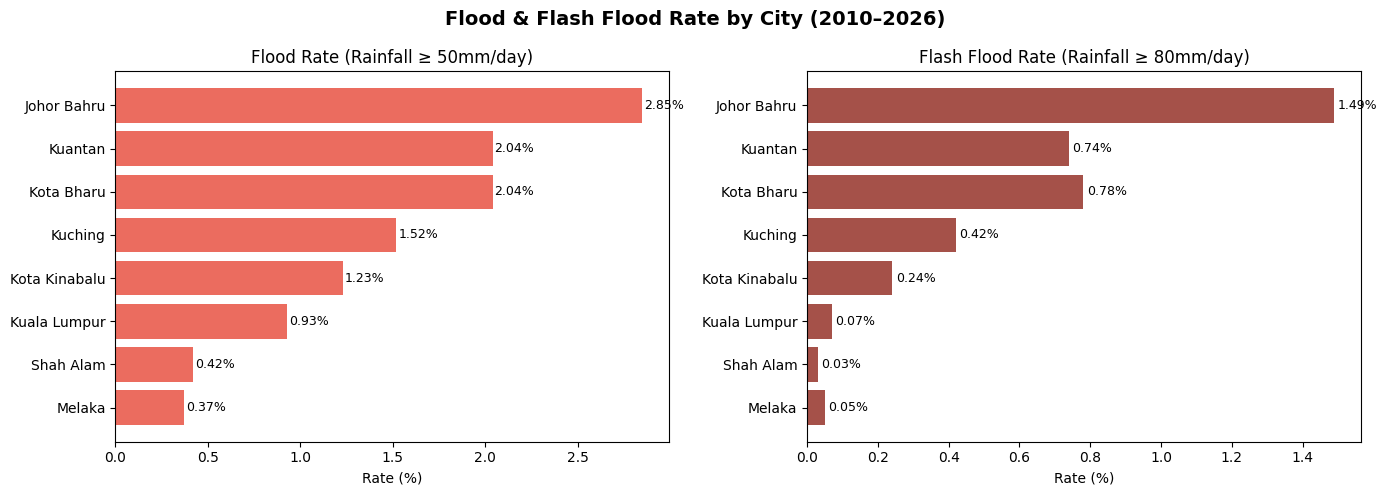

In [7]:
city_sorted = city_summary.sort_values('Flood_Rate_%', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Flood & Flash Flood Rate by City (2010–2026)', fontsize=14, fontweight='bold')

for ax, col, color, label in [
    (axes[0], 'Flood_Rate_%',  '#e74c3c', 'Flood Rate (Rainfall ≥ 50mm/day)'),
    (axes[1], 'Flash_Rate_%',  '#922b21', 'Flash Flood Rate (Rainfall ≥ 80mm/day)')
]:
    ax.barh(city_sorted['City'], city_sorted[col], color=color, alpha=0.82)
    ax.set_xlabel('Rate (%)')
    ax.set_title(label)
    for i, v in enumerate(city_sorted[col]):
        ax.text(v + 0.01, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart01_flood_rate_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Chart 2: Flood Days by Month (All Cities Combined)

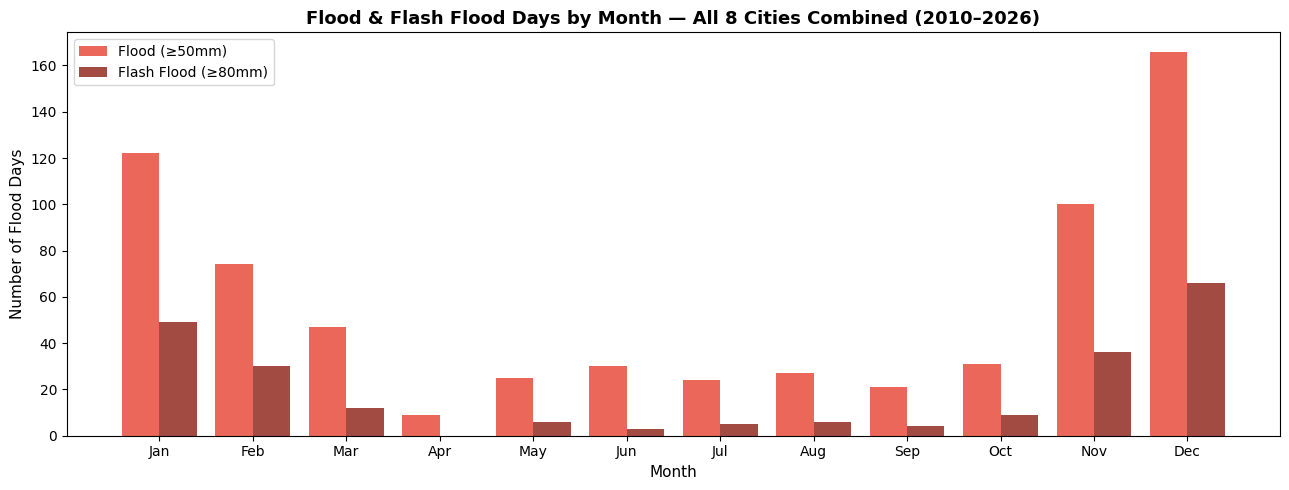

In [8]:
flood_month = df[df['Flood']==1].groupby('Month').size().reindex(range(1,13), fill_value=0)
flash_month = df[df['Flash_Flood']==1].groupby('Month').size().reindex(range(1,13), fill_value=0)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(12)
width = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, flood_month.values, width, label='Flood (≥50mm)',       color='#e74c3c', alpha=0.85)
ax.bar(x + width/2, flash_month.values, width, label='Flash Flood (≥80mm)', color='#922b21', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Flood Days', fontsize=11)
ax.set_title('Flood & Flash Flood Days by Month — All 8 Cities Combined (2010–2026)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart02_flood_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Chart 3: Monsoon vs Non-Monsoon Flood Rate by City

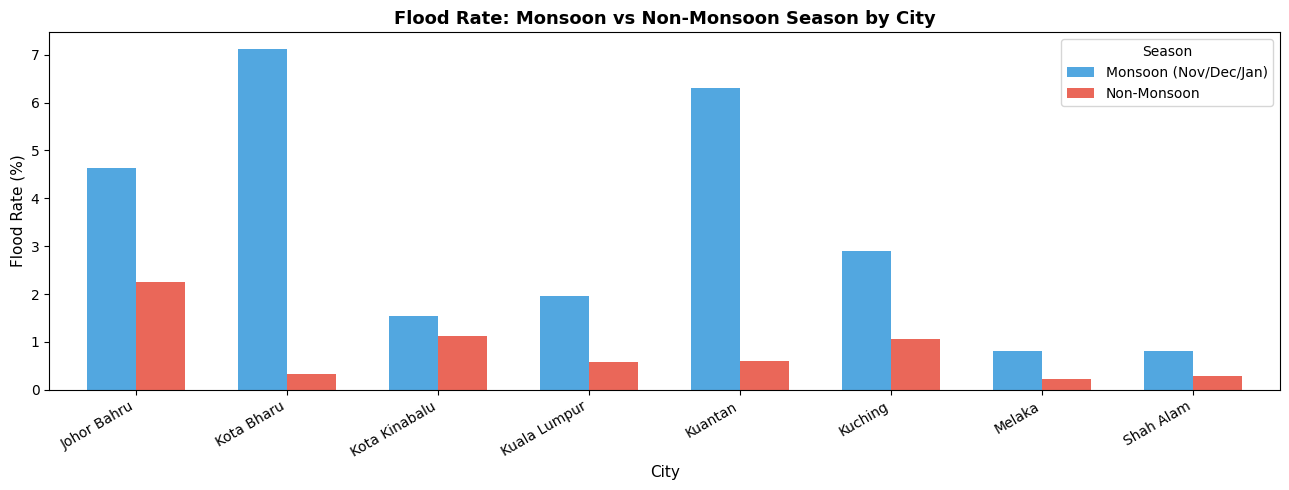

In [9]:
monsoon_df = df.groupby(['City','Is_Monsoon'])['Flood'].mean().reset_index()
monsoon_df['Flood_Rate_%'] = (monsoon_df['Flood'] * 100).round(2)
monsoon_df['Season'] = monsoon_df['Is_Monsoon'].map({1:'Monsoon (Nov/Dec/Jan)', 0:'Non-Monsoon'})
pivot = monsoon_df.pivot(index='City', columns='Season', values='Flood_Rate_%').fillna(0)

pivot.plot(kind='bar', figsize=(13, 5), color=['#3498db','#e74c3c'], alpha=0.85, width=0.65)
plt.title('Flood Rate: Monsoon vs Non-Monsoon Season by City', fontsize=13, fontweight='bold')
plt.xlabel('City', fontsize=11)
plt.ylabel('Flood Rate (%)', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Season', fontsize=10)
plt.tight_layout()
plt.savefig('chart03_monsoon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Chart 4: Feature Correlation Heatmap

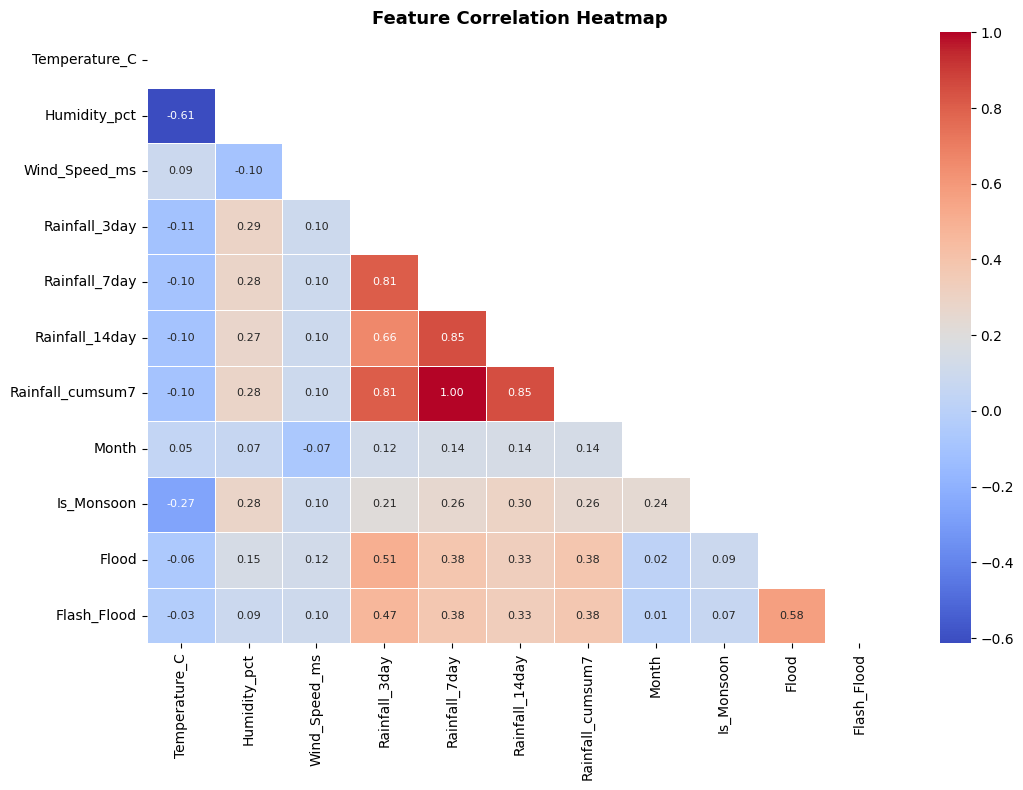

In [10]:
feat_cols = ['Temperature_C','Humidity_pct','Wind_Speed_ms',
             'Rainfall_3day','Rainfall_7day','Rainfall_14day',
             'Rainfall_cumsum7','Month','Is_Monsoon','Flood','Flash_Flood']
corr = df[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8}, mask=mask)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Chart 5: Rainfall Distribution — Flood vs No Flood Days

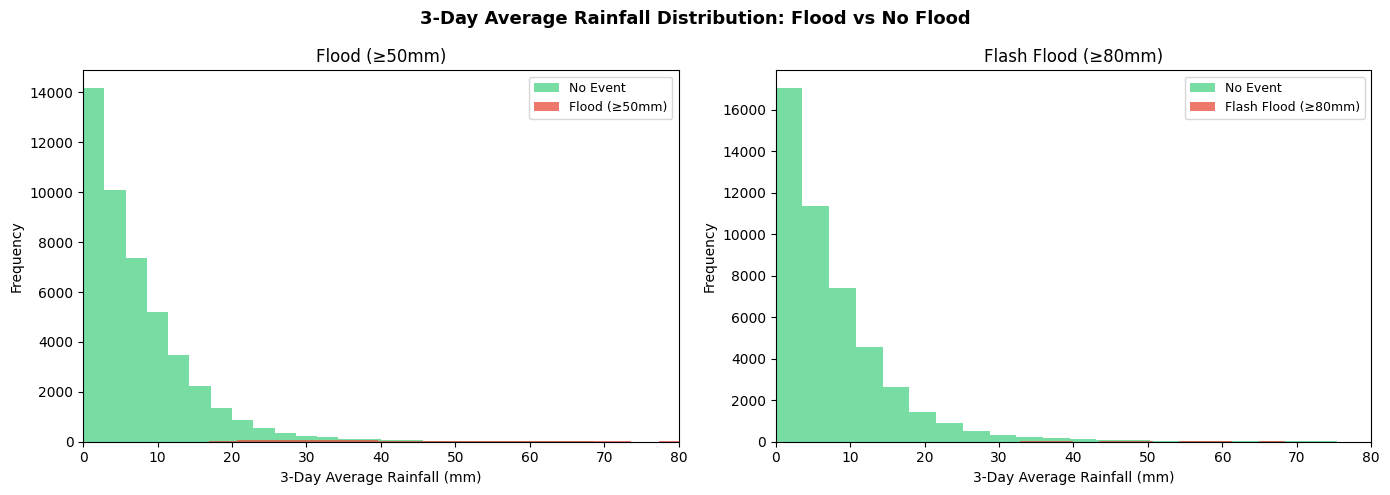

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3-Day Average Rainfall Distribution: Flood vs No Flood', fontsize=13, fontweight='bold')

for ax, col, label in [
    (axes[0], 'Flood',       'Flood (≥50mm)'),
    (axes[1], 'Flash_Flood', 'Flash Flood (≥80mm)')
]:
    df[df[col]==0]['Rainfall_3day'].plot(kind='hist', bins=60, alpha=0.65,
                                         color='#2ecc71', label='No Event', ax=ax)
    df[df[col]==1]['Rainfall_3day'].plot(kind='hist', bins=60, alpha=0.75,
                                         color='#e74c3c', label=label,    ax=ax)
    ax.set_xlabel('3-Day Average Rainfall (mm)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 80)

plt.tight_layout()
plt.savefig('chart05_rainfall_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Chart 6: Annual Flood Days Trend Over Years

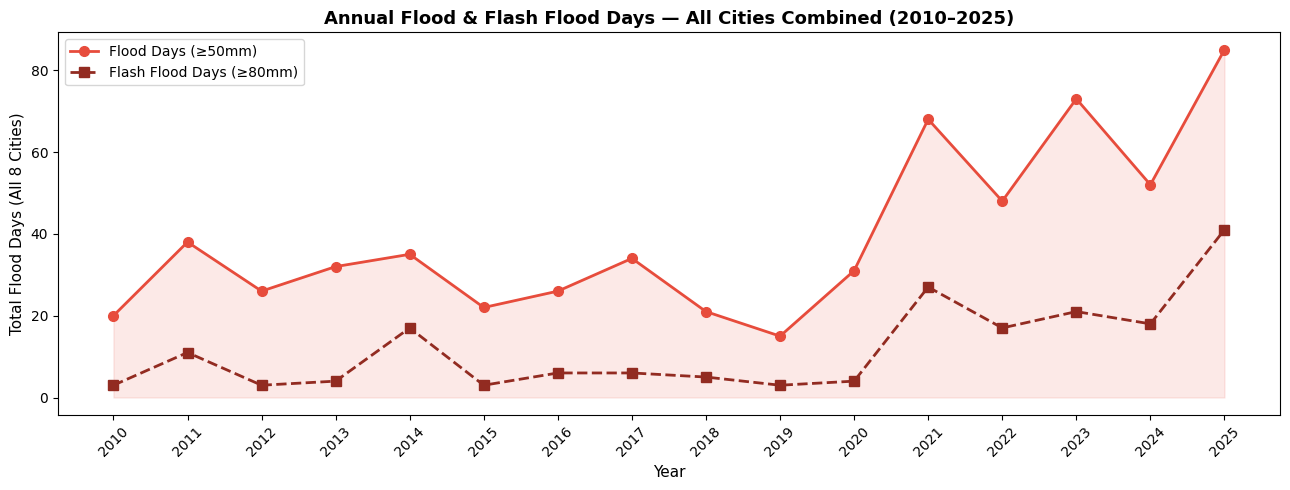

In [12]:
df['Year'] = df['DATE'].dt.year
annual = df.groupby('Year')[['Flood','Flash_Flood']].sum().reset_index()
annual = annual[annual['Year'] < 2026]  # exclude incomplete 2026

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(annual['Year'], annual['Flood'],       marker='o', color='#e74c3c',
        linewidth=2, markersize=7, label='Flood Days (≥50mm)')
ax.plot(annual['Year'], annual['Flash_Flood'], marker='s', color='#922b21',
        linewidth=2, markersize=7, label='Flash Flood Days (≥80mm)', linestyle='--')
ax.fill_between(annual['Year'], annual['Flood'], alpha=0.12, color='#e74c3c')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total Flood Days (All 8 Cities)', fontsize=11)
ax.set_title('Annual Flood & Flash Flood Days — All Cities Combined (2010–2025)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(annual['Year'])
ax.set_xticklabels(annual['Year'], rotation=45)
plt.tight_layout()
plt.savefig('chart06_annual_flood_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Chart 7: Flood Days Heatmap (City × Month)

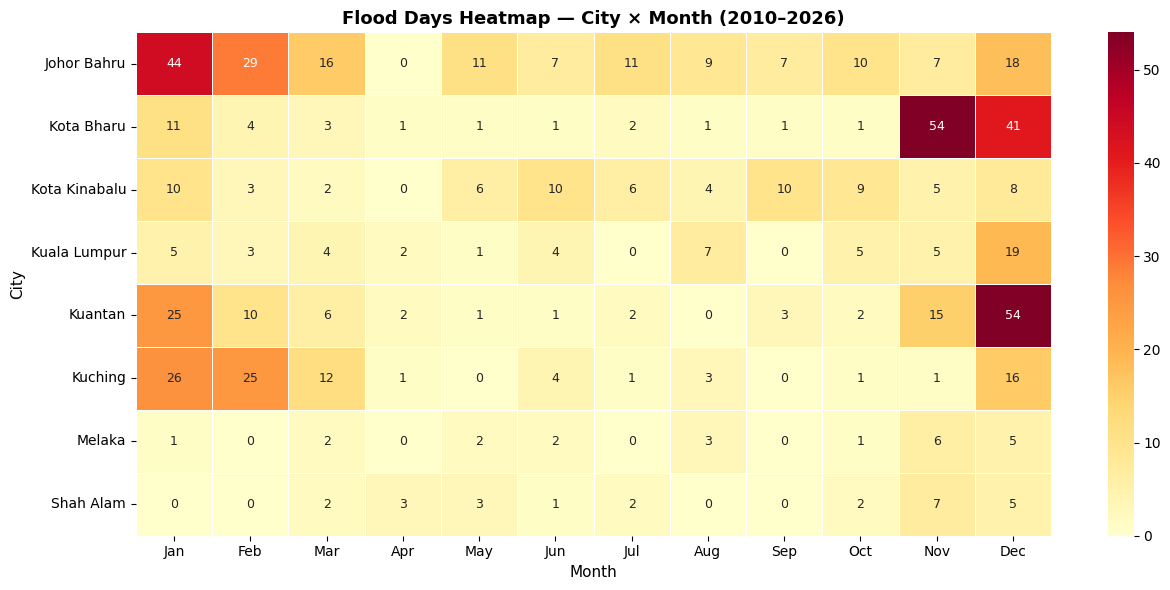

In [13]:
heatmap_data = df[df['Flood']==1].groupby(['City','Month']).size().unstack(fill_value=0)
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(13, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Flood Days Heatmap — City × Month (2010–2026)', fontsize=13, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('City', fontsize=11)
plt.tight_layout()
plt.savefig('chart07_flood_heatmap_city_month.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Define Features, Labels, Split & Balance

In [14]:
FEATURES = [
    'Temperature_C', 'Humidity_pct', 'Wind_Speed_ms',
    'Rainfall_3day', 'Rainfall_7day', 'Rainfall_14day',
    'Rainfall_cumsum7', 'Month', 'Is_Monsoon'
]

X        = df[FEATURES]
y_flood  = df['Flood']
y_flash  = df['Flash_Flood']

# Normalize
scaler   = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES, index=X.index)

# Train/Test split — no shuffle to preserve time order
X_train, X_test, yf_train, yf_test   = train_test_split(X_scaled, y_flood, test_size=0.2, random_state=42, shuffle=False)
_,       _,      yff_train, yff_test  = train_test_split(X_scaled, y_flash, test_size=0.2, random_state=42, shuffle=False)

def balance_classes(X_tr, y_tr):
    data = X_tr.copy()
    data['__label__'] = y_tr.values
    maj = data[data['__label__']==0]
    minn = data[data['__label__']==1]
    minn_up = resample(minn, replace=True, n_samples=len(maj), random_state=42)
    bal = pd.concat([maj, minn_up])
    return bal.drop('__label__', axis=1), bal['__label__']

X_train_flood, y_train_flood = balance_classes(X_train, yf_train)
X_train_flash, y_train_flash = balance_classes(X_train, yff_train)

print('=== DATA SPLIT & BALANCE ===')
print(f'Train : {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Flood balanced  — Class 0: {(y_train_flood==0).sum():,} | Class 1: {y_train_flood.sum():,}')
print(f'Flash balanced  — Class 0: {(y_train_flash==0).sum():,} | Class 1: {y_train_flash.sum():,}')

=== DATA SPLIT & BALANCE ===
Train : 37,893 rows | Test: 9,474 rows
Flood balanced  — Class 0: 37,258 | Class 1: 37,258
Flash balanced  — Class 0: 37,672 | Class 1: 37,672


## Step 12 — Define Models & Evaluation Function

In [15]:
MODEL_NAMES = ['Decision Tree', 'Random Forest', 'XGBoost']

def get_models():
    return {
        'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost':       XGBClassifier(n_estimators=100, random_state=42,
                                       eval_metric='logloss', verbosity=0)
    }

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, pred), 4),
        'Precision': round(precision_score(y_te, pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, pred, zero_division=0), 4),
        'F1':        round(f1_score(y_te, pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_te, proba), 4),
        '_pred':  pred,
        '_proba': proba,
        '_model': model
    }

## Step 13 — Train & Evaluate: Task 1 — FLOOD Prediction (≥50mm)

In [16]:
print('='*55)
print('  TASK 1: FLOOD PREDICTION (Rainfall >= 50mm/day)')
print('='*55)

flood_results = []
flood_trained = {}

for name, model in get_models().items():
    res = evaluate_model(name, model, X_train_flood, y_train_flood, X_test, yf_test)
    flood_trained[name] = res
    flood_results.append({k: v for k, v in res.items() if not k.startswith('_')})
    print(f'\n{name}:')
    for metric in ['Accuracy','Precision','Recall','F1','AUC-ROC']:
        print(f'  {metric:<10}: {res[metric]}')

flood_df = pd.DataFrame(flood_results)
print('\n=== FLOOD — SUMMARY TABLE ===')
print(flood_df.to_string(index=False))

  TASK 1: FLOOD PREDICTION (Rainfall >= 50mm/day)

Decision Tree:
  Accuracy  : 0.9723
  Precision : 0.115
  Recall    : 0.8049
  F1        : 0.2012
  AUC-ROC   : 0.8925

Random Forest:
  Accuracy  : 0.9954
  Precision : 0.3333
  Recall    : 0.0732
  F1        : 0.12
  AUC-ROC   : 0.9479

XGBoost:
  Accuracy  : 0.993
  Precision : 0.2642
  Recall    : 0.3415
  F1        : 0.2979
  AUC-ROC   : 0.9824

=== FLOOD — SUMMARY TABLE ===
        Model  Accuracy  Precision  Recall     F1  AUC-ROC
Decision Tree    0.9723     0.1150  0.8049 0.2012   0.8925
Random Forest    0.9954     0.3333  0.0732 0.1200   0.9479
      XGBoost    0.9930     0.2642  0.3415 0.2979   0.9824


## Step 14 — Train & Evaluate: Task 2 — FLASH FLOOD Prediction (≥80mm)

In [17]:
print('='*55)
print('  TASK 2: FLASH FLOOD PREDICTION (Rainfall >= 80mm/day)')
print('='*55)

flash_results = []
flash_trained = {}

for name, model in get_models().items():
    res = evaluate_model(name, model, X_train_flash, y_train_flash, X_test, yff_test)
    flash_trained[name] = res
    flash_results.append({k: v for k, v in res.items() if not k.startswith('_')})
    print(f'\n{name}:')
    for metric in ['Accuracy','Precision','Recall','F1','AUC-ROC']:
        print(f'  {metric:<10}: {res[metric]}')

flash_df = pd.DataFrame(flash_results)
print('\n=== FLASH FLOOD — SUMMARY TABLE ===')
print(flash_df.to_string(index=False))

  TASK 2: FLASH FLOOD PREDICTION (Rainfall >= 80mm/day)

Decision Tree:
  Accuracy  : 0.9979
  Precision : 0.0588
  Recall    : 0.2
  F1        : 0.0909
  AUC-ROC   : 0.5993

Random Forest:
  Accuracy  : 0.9995
  Precision : 0.5
  Recall    : 0.2
  F1        : 0.2857
  AUC-ROC   : 0.7968

XGBoost:
  Accuracy  : 0.9992
  Precision : 0.2
  Recall    : 0.2
  F1        : 0.2
  AUC-ROC   : 0.9651

=== FLASH FLOOD — SUMMARY TABLE ===
        Model  Accuracy  Precision  Recall     F1  AUC-ROC
Decision Tree    0.9979     0.0588     0.2 0.0909   0.5993
Random Forest    0.9995     0.5000     0.2 0.2857   0.7968
      XGBoost    0.9992     0.2000     0.2 0.2000   0.9651


## Step 15 — Chart 8: Model Comparison Bar Chart (F1 & AUC)

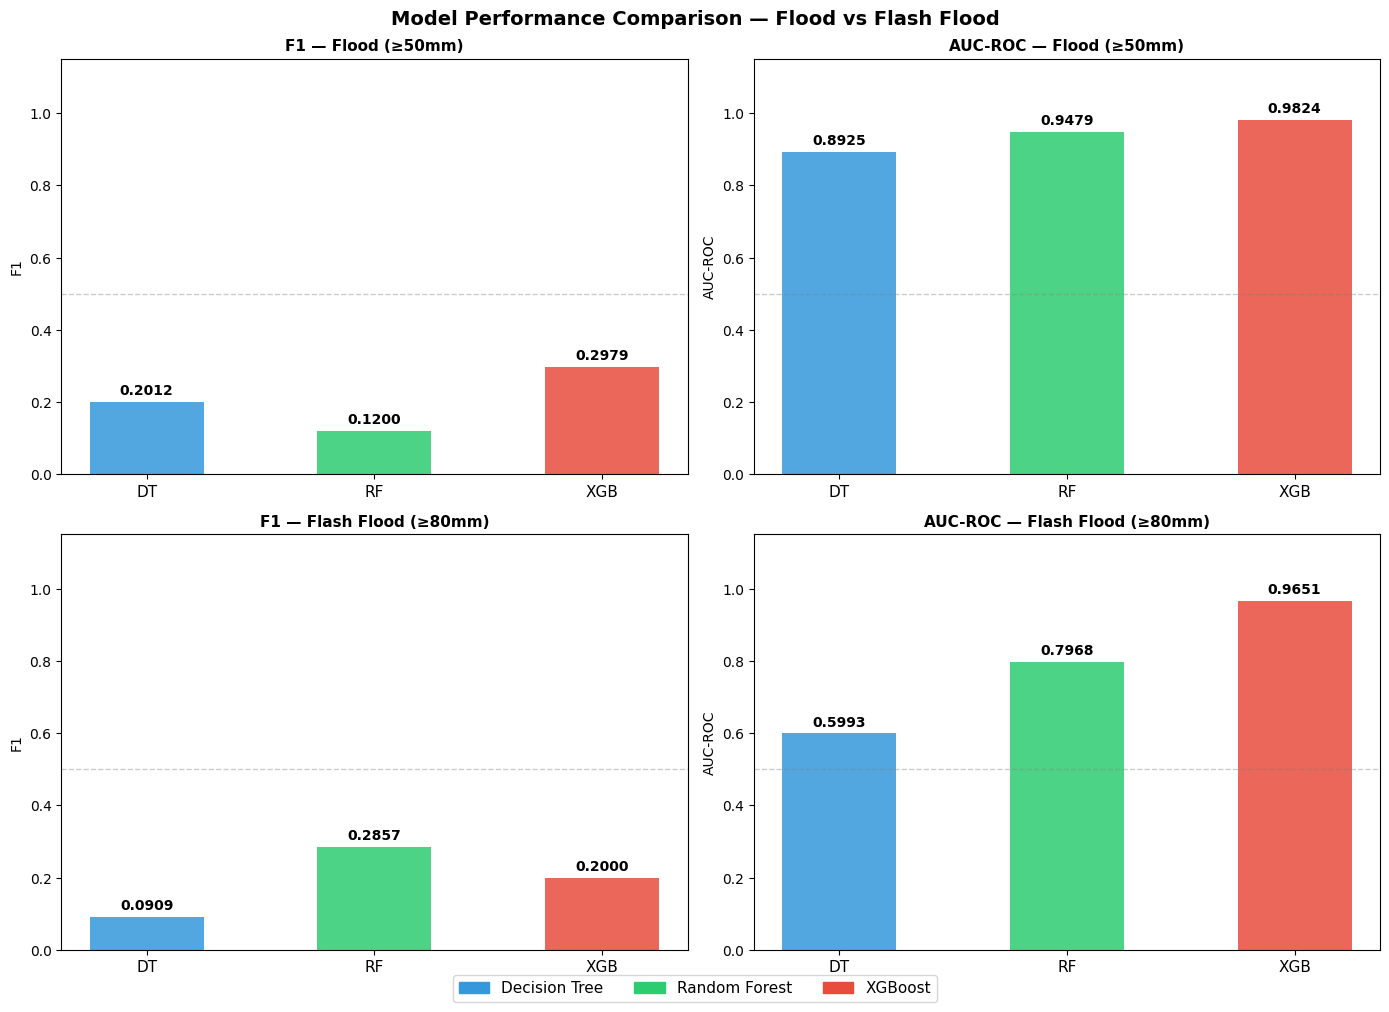

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison — Flood vs Flash Flood', fontsize=14, fontweight='bold')

bar_colors = ['#3498db','#2ecc71','#e74c3c']
x = np.arange(3)

for row, (task, result_df) in enumerate([
    ('Flood (≥50mm)',       flood_df),
    ('Flash Flood (≥80mm)', flash_df)
]):
    for col, metric in enumerate(['F1', 'AUC-ROC']):
        ax = axes[row][col]
        vals = result_df[metric].values
        bars = ax.bar(x, vals, color=bar_colors, alpha=0.85, width=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(['DT', 'RF', 'XGB'], fontsize=11)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric, fontsize=10)
        ax.set_title(f'{metric} — {task}', fontsize=11, fontweight='bold')
        for i, v in enumerate(vals):
            ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)

# Legend
patches = [mpatches.Patch(color=c, label=n) for c, n in
           zip(bar_colors, ['Decision Tree','Random Forest','XGBoost'])]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('chart08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 16 — Chart 9: Confusion Matrices (All Models × Both Tasks)

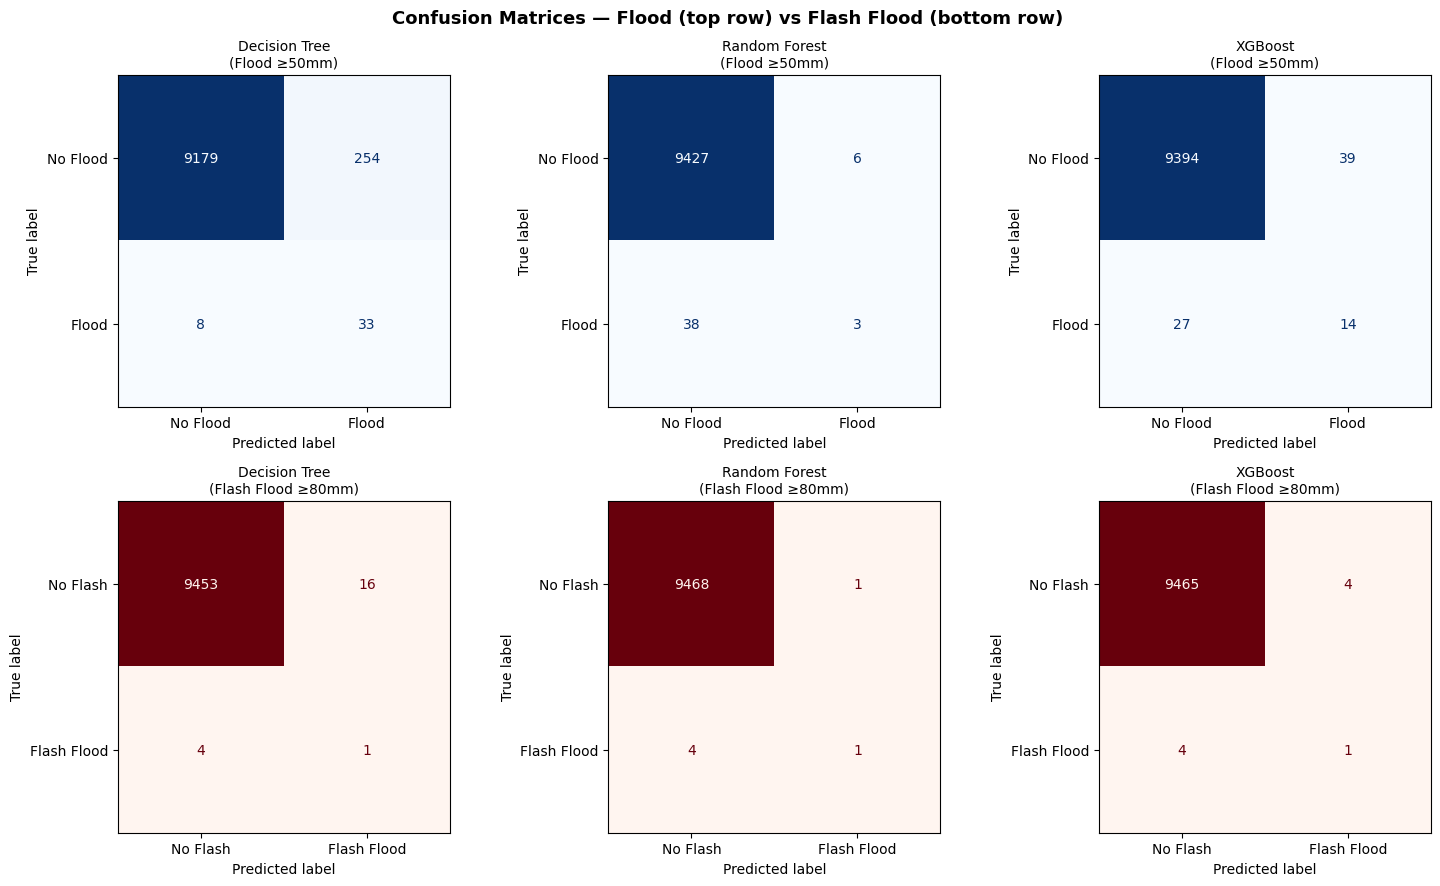

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Confusion Matrices — Flood (top row) vs Flash Flood (bottom row)',
             fontsize=13, fontweight='bold')

for col, name in enumerate(MODEL_NAMES):
    for row, (task_label, y_true, trained, cmap, labels) in enumerate([
        ('Flood ≥50mm',       yf_test,  flood_trained, 'Blues', ['No Flood',  'Flood']),
        ('Flash Flood ≥80mm', yff_test, flash_trained, 'Reds',  ['No Flash',  'Flash Flood'])
    ]):
        cm   = confusion_matrix(y_true, trained[name]['_pred'])
        disp = ConfusionMatrixDisplay(cm, display_labels=labels)
        disp.plot(ax=axes[row][col], colorbar=False, cmap=cmap)
        axes[row][col].set_title(f'{name}\n({task_label})', fontsize=10)

plt.tight_layout()
plt.savefig('chart09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 17 — Chart 10: ROC Curves (Both Tasks)

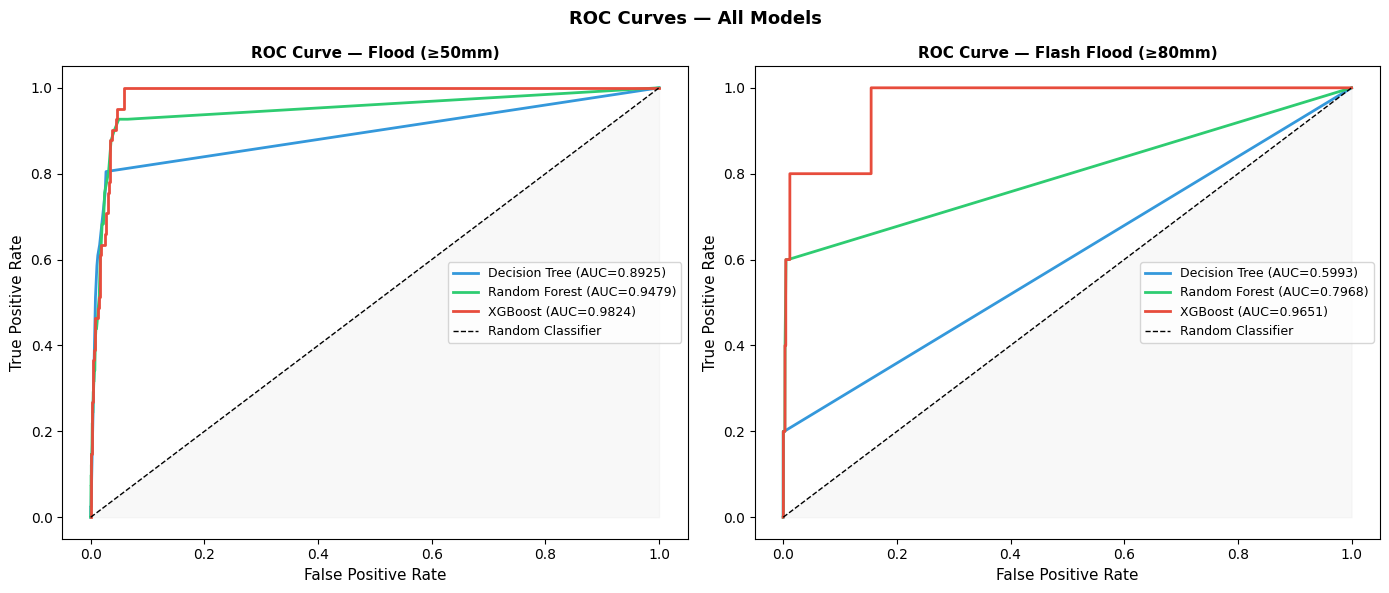

In [20]:
colors = ['#3498db','#2ecc71','#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves — All Models', fontsize=13, fontweight='bold')

for ax, task_label, y_true, trained in [
    (axes[0], 'Flood (≥50mm)',       yf_test,  flood_trained),
    (axes[1], 'Flash Flood (≥80mm)', yff_test, flash_trained)
]:
    for name, color in zip(MODEL_NAMES, colors):
        fpr, tpr, _ = roc_curve(y_true, trained[name]['_proba'])
        auc = trained[name]['AUC-ROC']
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
    ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve — {task_label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 18 — Chart 11: Precision-Recall Curves

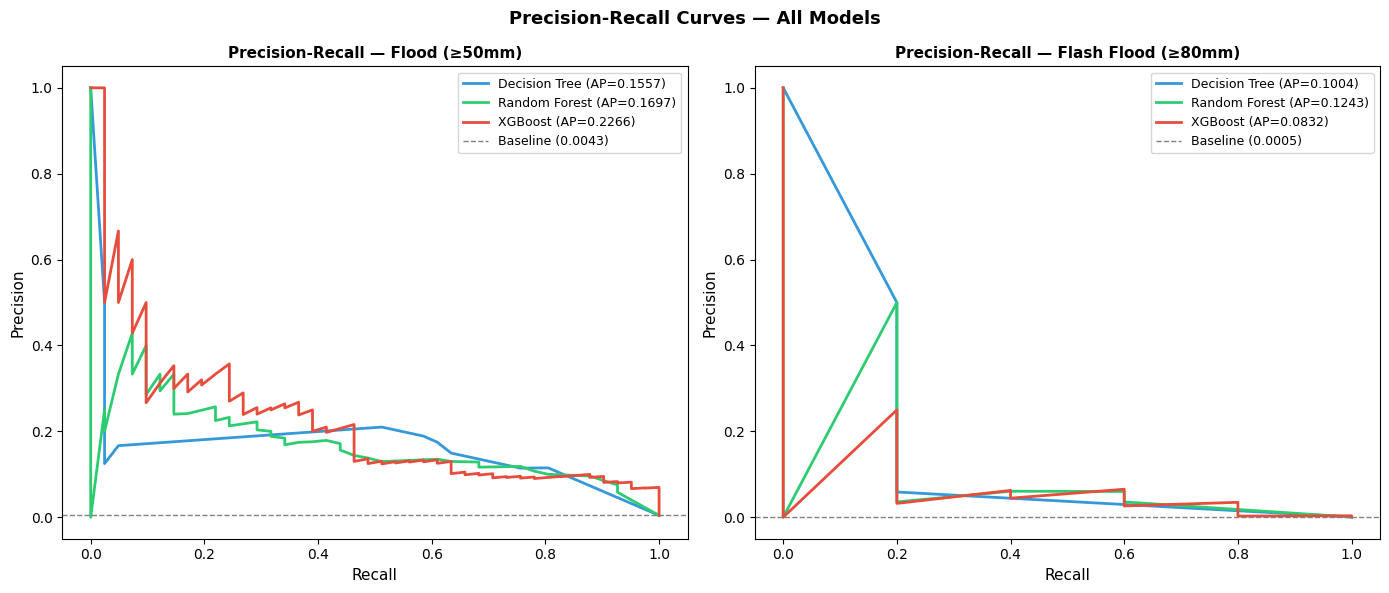

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')

for ax, task_label, y_true, trained in [
    (axes[0], 'Flood (≥50mm)',       yf_test,  flood_trained),
    (axes[1], 'Flash Flood (≥80mm)', yff_test, flash_trained)
]:
    for name, color in zip(MODEL_NAMES, colors):
        prec, rec, _ = precision_recall_curve(y_true, trained[name]['_proba'])
        ap = average_precision_score(y_true, trained[name]['_proba'])
        ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')
    baseline = y_true.mean()
    ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
               label=f'Baseline ({baseline:.4f})')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'Precision-Recall — {task_label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart11_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 19 — Chart 12: Feature Importance (All 3 Models × Both Tasks)

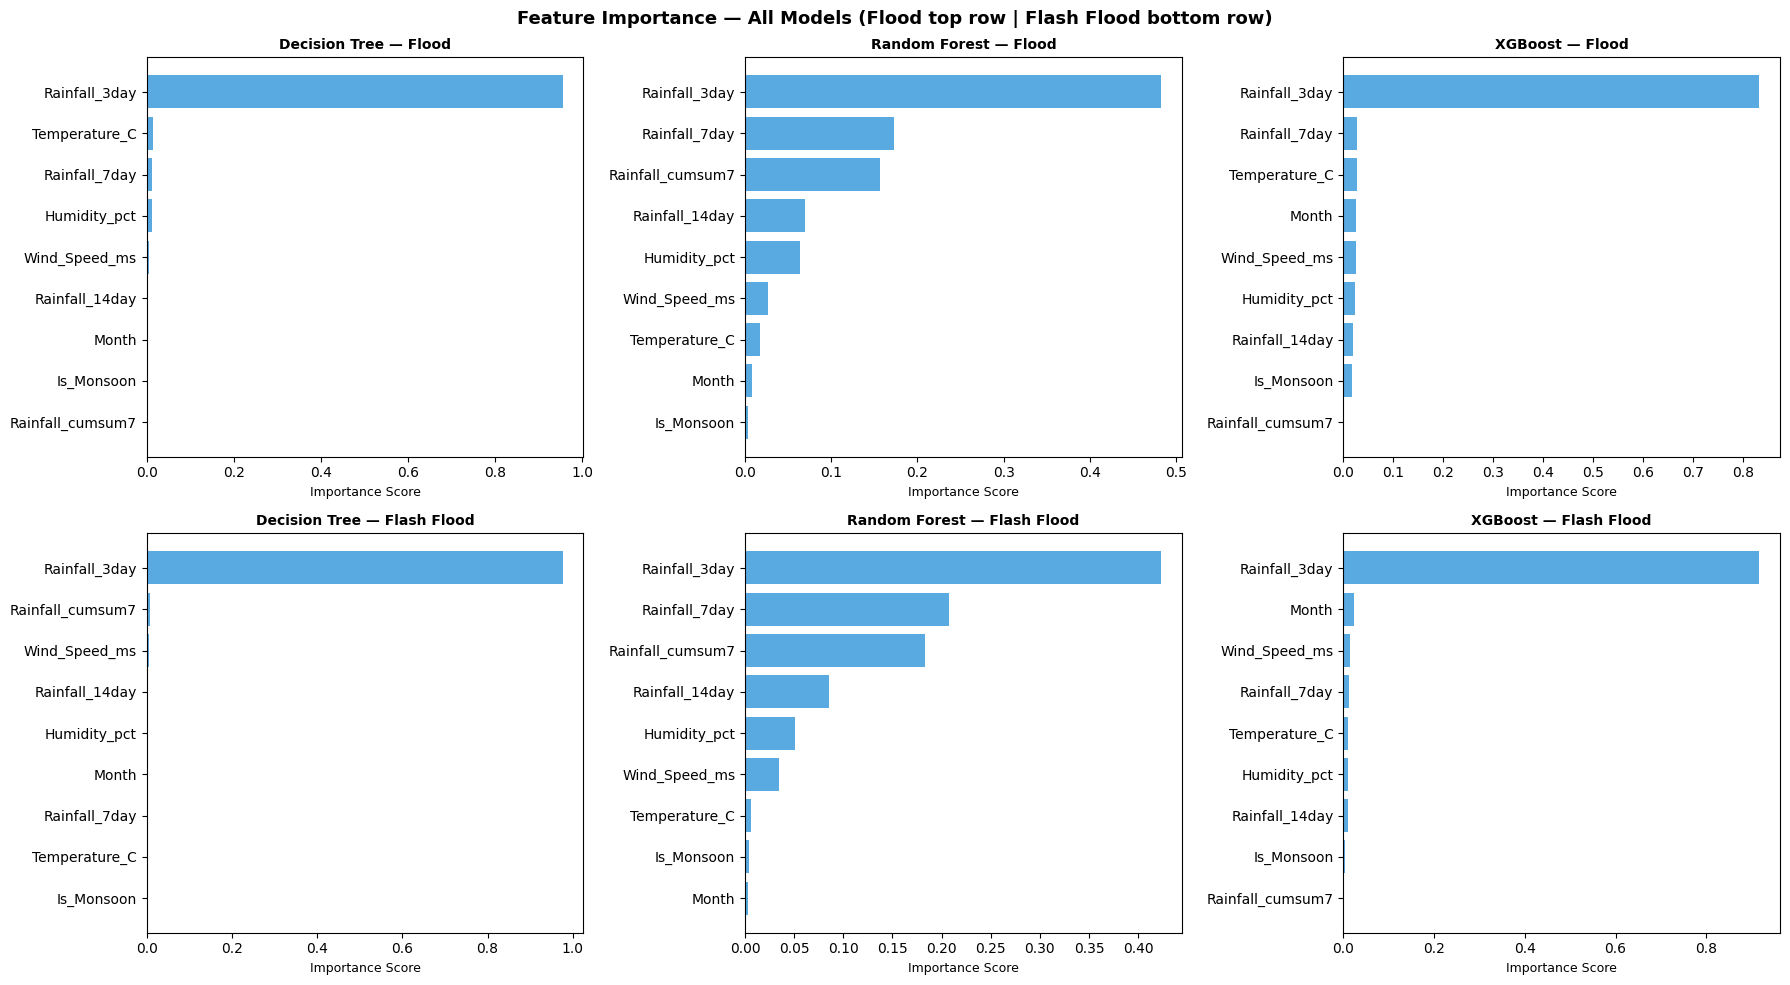

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Importance — All Models (Flood top row | Flash Flood bottom row)',
             fontsize=13, fontweight='bold')

for row, (task_label, trained) in enumerate([
    ('Flood',       flood_trained),
    ('Flash Flood', flash_trained)
]):
    for col, name in enumerate(MODEL_NAMES):
        model = trained[name]['_model']
        imp   = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
        axes[row][col].barh(imp.index, imp.values, color='#3498db', alpha=0.82)
        axes[row][col].set_title(f'{name} — {task_label}', fontsize=10, fontweight='bold')
        axes[row][col].set_xlabel('Importance Score', fontsize=9)

plt.tight_layout()
plt.savefig('chart12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 20 — Chart 13: Decision Tree Visualization (Simplified)

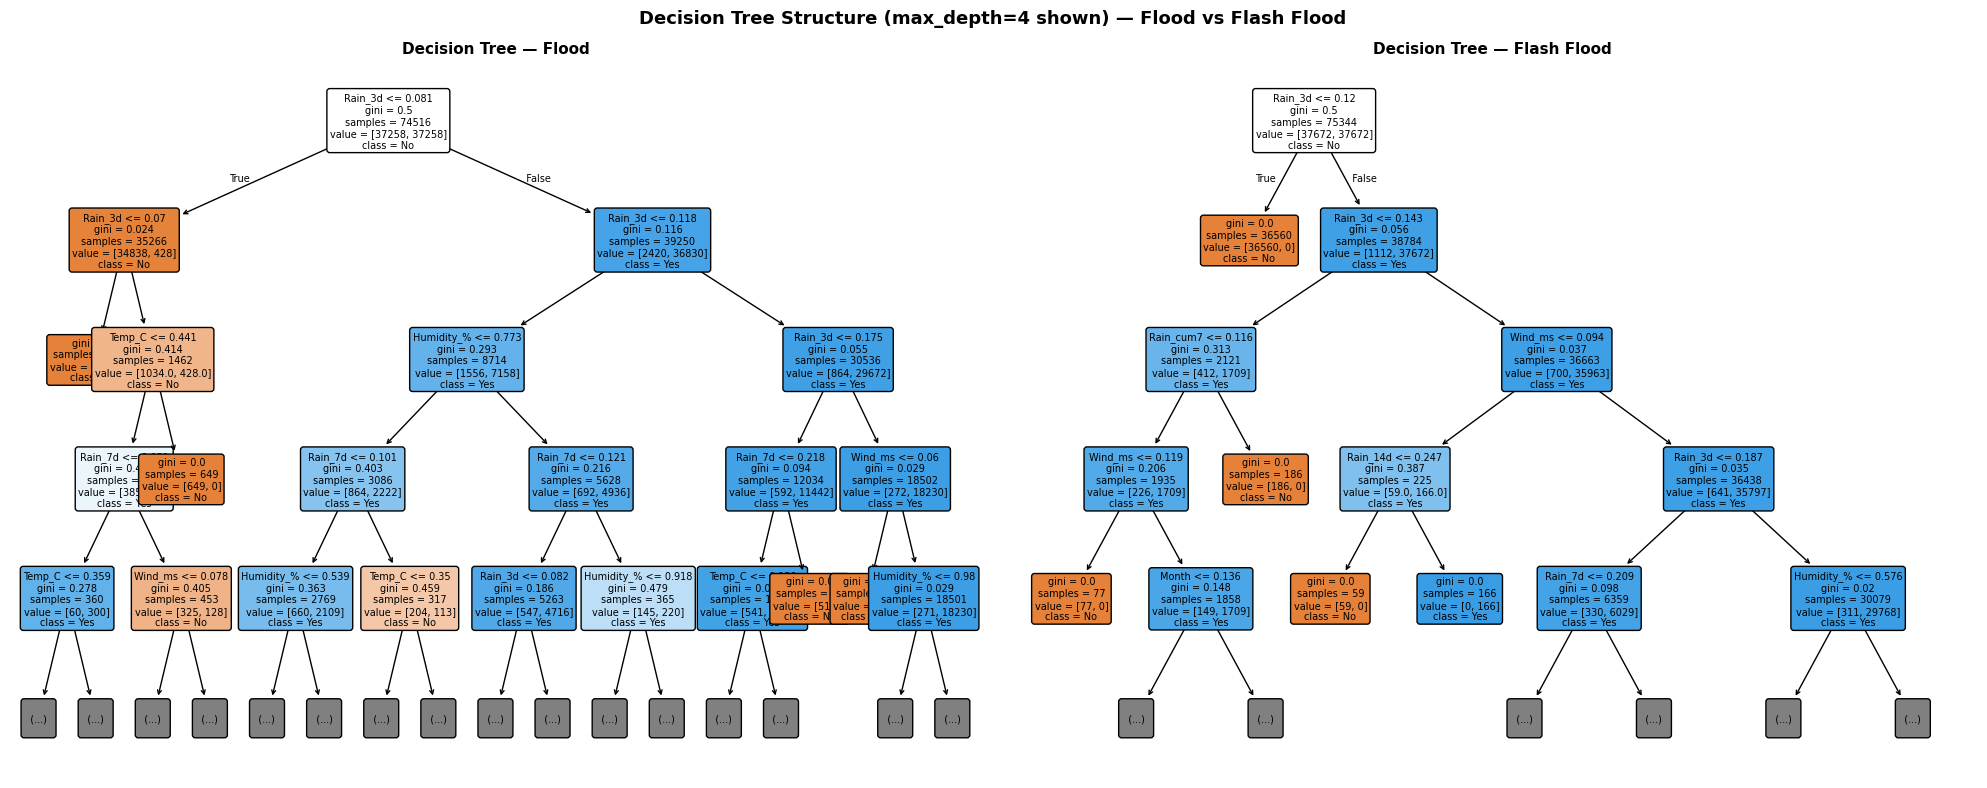

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Decision Tree Structure (max_depth=4 shown) — Flood vs Flash Flood',
             fontsize=13, fontweight='bold')

feature_names_clean = ['Temp_C','Humidity_%','Wind_ms',
                        'Rain_3d','Rain_7d','Rain_14d',
                        'Rain_cum7','Month','Is_Monsoon']

for ax, task_label, trained in [
    (axes[0], 'Flood',       flood_trained),
    (axes[1], 'Flash Flood', flash_trained)
]:
    plot_tree(trained['Decision Tree']['_model'],
              max_depth=4,
              feature_names=feature_names_clean,
              class_names=['No','Yes'],
              filled=True, rounded=True,
              fontsize=7, ax=ax)
    ax.set_title(f'Decision Tree — {task_label}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart13_decision_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 21 — 5-Fold Cross Validation

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=False)
cv_flood = {}
cv_flash = {}

print('='*60)
print('5-FOLD CROSS VALIDATION RESULTS')
print('='*60)

for task_label, y_lbl, cv_store in [
    ('FLOOD (>=50mm)',       y_flood, cv_flood),
    ('FLASH FLOOD (>=80mm)', y_flash, cv_flash)
]:
    print(f'\n--- {task_label} ---')
    for name, model in get_models().items():
        f1s  = cross_val_score(model, X_scaled, y_lbl, cv=skf, scoring='f1',      n_jobs=-1)
        aucs = cross_val_score(model, X_scaled, y_lbl, cv=skf, scoring='roc_auc', n_jobs=-1)
        cv_store[name] = {'f1': f1s, 'auc': aucs}
        print(f'  {name}:')
        print(f'    F1  : {f1s.mean():.4f} ± {f1s.std():.4f}  | folds: {np.round(f1s,4)}')
        print(f'    AUC : {aucs.mean():.4f} ± {aucs.std():.4f}  | folds: {np.round(aucs,4)}')

5-FOLD CROSS VALIDATION RESULTS

--- FLOOD (>=50mm) ---
  Decision Tree:
    F1  : 0.2419 ± 0.1169  | folds: [0.3824 0.2481 0.2752 0.2772 0.0268]
    AUC : 0.8778 ± 0.0515  | folds: [0.9469 0.917  0.8773 0.8483 0.7998]
  Random Forest:
    F1  : 0.1953 ± 0.1070  | folds: [0.3824 0.1946 0.1164 0.2131 0.0699]
    AUC : 0.9634 ± 0.0189  | folds: [0.9852 0.9695 0.9291 0.9729 0.9603]
  XGBoost:
    F1  : 0.2139 ± 0.1251  | folds: [0.4457 0.1744 0.21   0.1705 0.069 ]
    AUC : 0.9620 ± 0.0132  | folds: [0.9827 0.966  0.955  0.9635 0.9426]

--- FLASH FLOOD (>=80mm) ---
  Decision Tree:
    F1  : 0.2370 ± 0.1017  | folds: [0.1455 0.3288 0.1176 0.3789 0.2143]
    AUC : 0.7219 ± 0.0483  | folds: [0.7667 0.7564 0.6374 0.7501 0.6987]
  Random Forest:
    F1  : 0.1632 ± 0.1068  | folds: [0.2    0.1034 0.     0.32   0.1923]
    AUC : 0.9620 ± 0.0196  | folds: [0.9633 0.985  0.9776 0.9554 0.9288]
  XGBoost:
    F1  : 0.1488 ± 0.0495  | folds: [0.2353 0.093  0.125  0.1682 0.1224]
    AUC : 0.9662 ± 0.

## Step 22 — Chart 14: Cross Validation Results

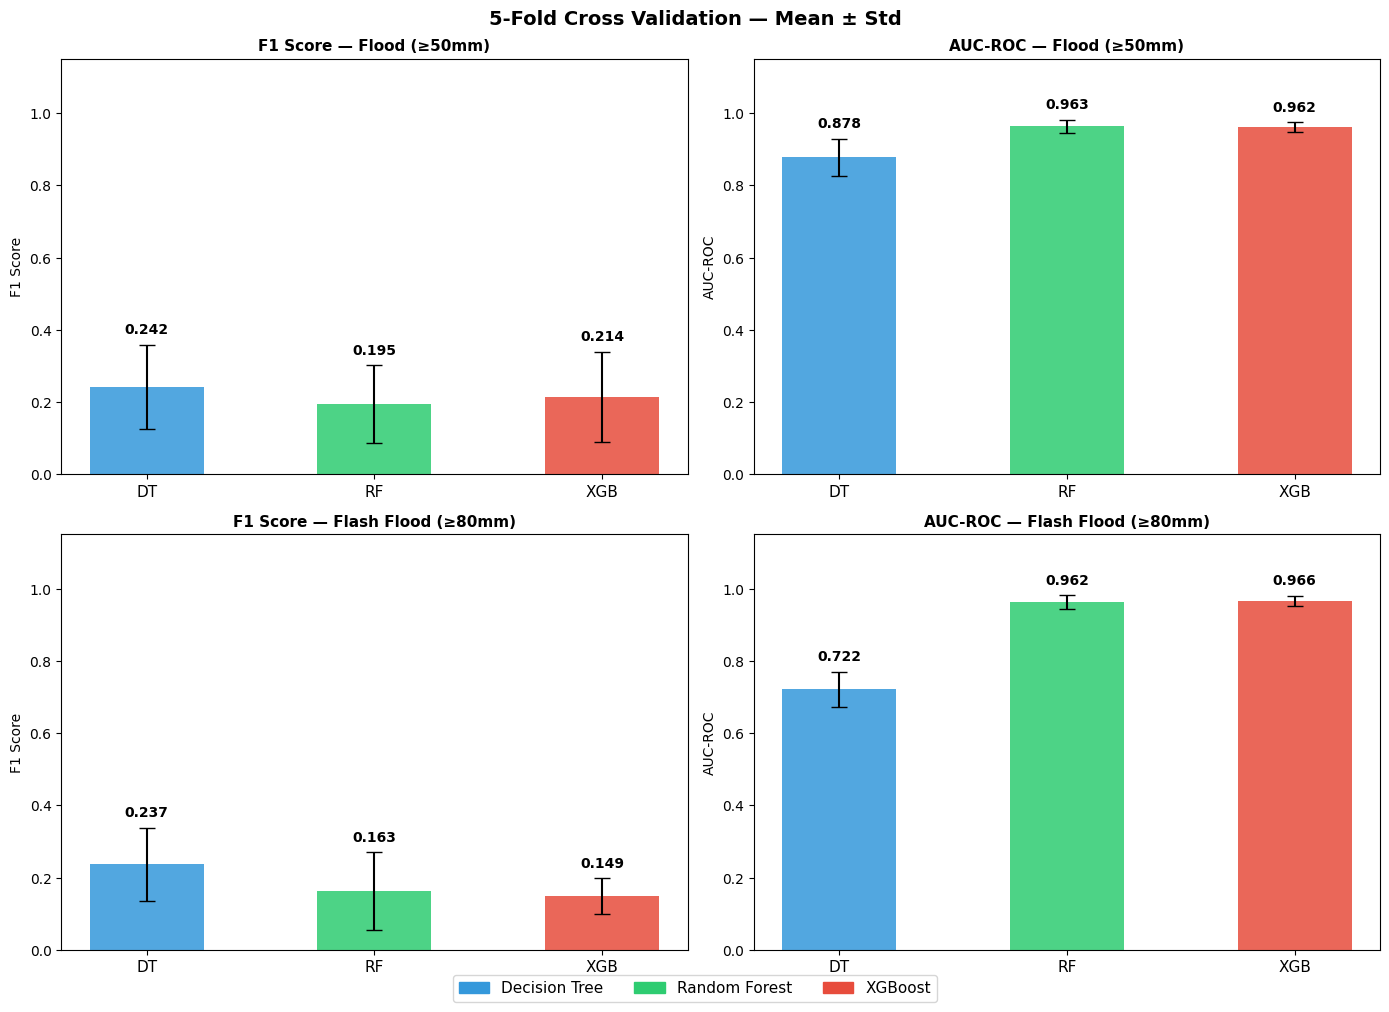

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('5-Fold Cross Validation — Mean ± Std', fontsize=14, fontweight='bold')
x = np.arange(3)

for row, (task, cv_store) in enumerate([
    ('Flood (≥50mm)',       cv_flood),
    ('Flash Flood (≥80mm)', cv_flash)
]):
    f1_means  = [cv_store[n]['f1'].mean()  for n in MODEL_NAMES]
    f1_stds   = [cv_store[n]['f1'].std()   for n in MODEL_NAMES]
    auc_means = [cv_store[n]['auc'].mean() for n in MODEL_NAMES]
    auc_stds  = [cv_store[n]['auc'].std()  for n in MODEL_NAMES]

    for col, (means, stds, metric) in enumerate([
        (f1_means,  f1_stds,  'F1 Score'),
        (auc_means, auc_stds, 'AUC-ROC')
    ]):
        ax = axes[row][col]
        ax.bar(x, means, width=0.5, yerr=stds, capsize=6,
               color=bar_colors, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(['DT','RF','XGB'], fontsize=11)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric, fontsize=10)
        ax.set_title(f'{metric} — {task}', fontsize=11, fontweight='bold')
        for i, (m, s) in enumerate(zip(means, stds)):
            ax.text(i, m + s + 0.03, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

patches = [mpatches.Patch(color=c, label=n) for c, n in
           zip(bar_colors, MODEL_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.savefig('chart14_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 23 — Chart 15: City-Level Performance (Best Model — Random Forest)

     City  Test_Days  Flood_Days     F1  AUC-ROC  Recall  Precision
   Melaka       3553          16 0.0000   0.9494    0.00     0.0000
Shah Alam       5921          25 0.1765   0.9465    0.12     0.3333


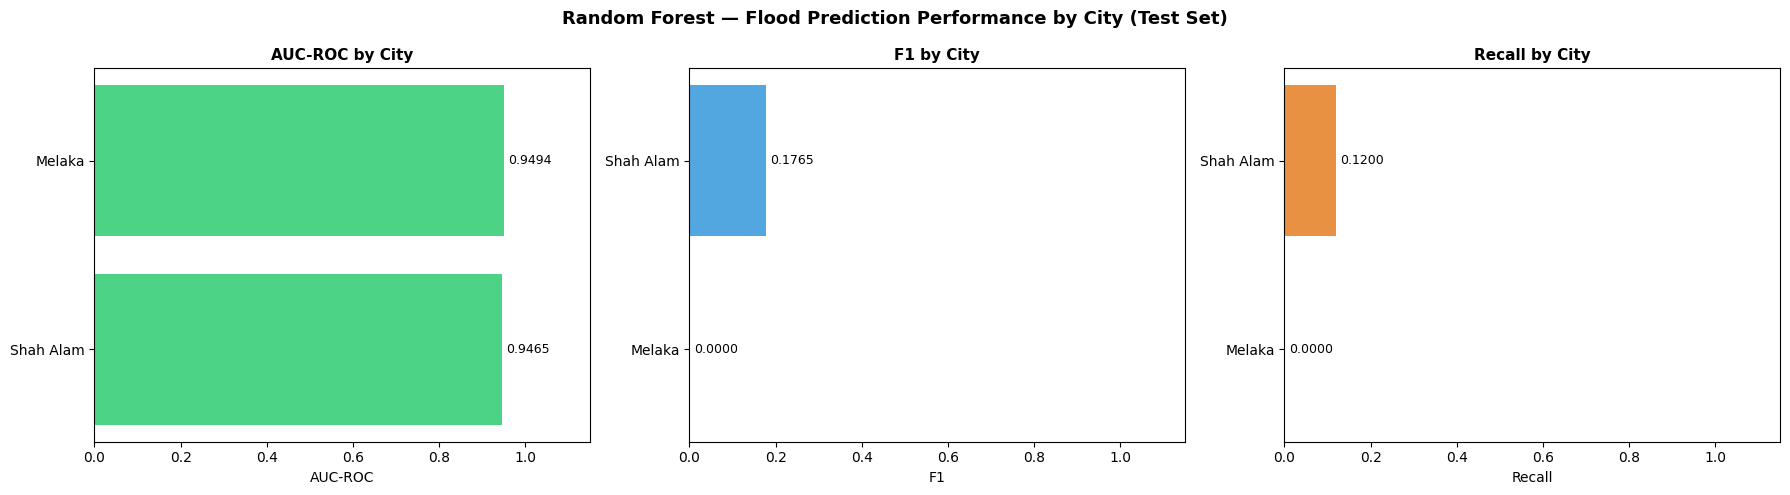

In [26]:
city_perf = []
for city in sorted(df['City'].unique()):
    city_idx = [i for i in df[df['City']==city].index if i in X_test.index]
    if not city_idx:
        continue
    Xc = X_test.loc[city_idx]
    yc = yf_test.loc[city_idx]
    if yc.sum() == 0:
        continue
    rf = flood_trained['Random Forest']['_model']
    pred  = rf.predict(Xc)
    proba = rf.predict_proba(Xc)[:,1]
    city_perf.append({
        'City': city, 'Test_Days': len(yc), 'Flood_Days': int(yc.sum()),
        'F1':      round(f1_score(yc, pred, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(yc, proba), 4),
        'Recall':  round(recall_score(yc, pred, zero_division=0), 4),
        'Precision': round(precision_score(yc, pred, zero_division=0), 4)
    })

city_perf_df = pd.DataFrame(city_perf)
print(city_perf_df.to_string(index=False))

city_s = city_perf_df.sort_values('AUC-ROC', ascending=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Flood Prediction Performance by City (Test Set)',
             fontsize=13, fontweight='bold')

for ax, metric, color in [
    (axes[0], 'AUC-ROC',   '#2ecc71'),
    (axes[1], 'F1',        '#3498db'),
    (axes[2], 'Recall',    '#e67e22')
]:
    s = city_perf_df.sort_values(metric, ascending=True)
    axes[list(axes).index(ax)].barh(s['City'], s[metric], color=color, alpha=0.85)
    ax.set_xlabel(metric, fontsize=10)
    ax.set_title(f'{metric} by City', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.15)
    for i, v in enumerate(s[metric]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart15_city_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 24 — Statistical Significance Tests

In [27]:
print('='*65)
print('STATISTICAL SIGNIFICANCE TESTS (Paired t-test, α=0.05)')
print('='*65)

for task, cv_store in [('FLOOD', cv_flood), ('FLASH FLOOD', cv_flash)]:
    dt_f1  = cv_store['Decision Tree']['f1']
    rf_f1  = cv_store['Random Forest']['f1']
    xgb_f1 = cv_store['XGBoost']['f1']

    _, p_dt_rf  = stats.ttest_rel(dt_f1, rf_f1)
    _, p_dt_xgb = stats.ttest_rel(dt_f1, xgb_f1)
    _, p_rf_xgb = stats.ttest_rel(rf_f1, xgb_f1)

    print(f'\n--- {task} ---')
    print(f'  DT  vs RF  : p = {p_dt_rf:.4f}   → {" SIGNIFICANT" if p_dt_rf  < 0.05 else "➖ Not significant"}')
    print(f'  DT  vs XGB : p = {p_dt_xgb:.4f}   → {" SIGNIFICANT" if p_dt_xgb < 0.05 else "➖ Not significant"}')
    print(f'  RF  vs XGB : p = {p_rf_xgb:.4f}   → {" SIGNIFICANT" if p_rf_xgb < 0.05 else "➖ Not significant"}')

STATISTICAL SIGNIFICANCE TESTS (Paired t-test, α=0.05)

--- FLOOD ---
  DT  vs RF  : p = 0.2422   → ➖ Not significant
  DT  vs XGB : p = 0.4544   → ➖ Not significant
  RF  vs XGB : p = 0.5098   → ➖ Not significant

--- FLASH FLOOD ---
  DT  vs RF  : p = 0.1914   → ➖ Not significant
  DT  vs XGB : p = 0.2297   → ➖ Not significant
  RF  vs XGB : p = 0.7745   → ➖ Not significant


## Step 25 — Final Summary & Save All Results

In [29]:
print('='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)
print('\n--- Task 1: FLOOD PREDICTION (>=50mm) ---')
print(flood_df.to_string(index=False))
print('\n--- Task 2: FLASH FLOOD PREDICTION (>=80mm) ---')
print(flash_df.to_string(index=False))

cv_rows = []
for task, cv_store in [('Flood', cv_flood), ('Flash Flood', cv_flash)]:
    for name in MODEL_NAMES:
        cv_rows.append({
            'Task': task, 'Model': name,
            'F1_Mean':  round(cv_store[name]['f1'].mean(),  4),
            'F1_Std':   round(cv_store[name]['f1'].std(),   4),
            'AUC_Mean': round(cv_store[name]['auc'].mean(), 4),
            'AUC_Std':  round(cv_store[name]['auc'].std(),  4)
        })
cv_summary_df = pd.DataFrame(cv_rows)
print('\n--- 5-Fold Cross Validation ---')
print(cv_summary_df.to_string(index=False))

# Save CSVs
flood_df.to_csv('results_flood_single_split.csv',      index=False)
flash_df.to_csv('results_flash_single_split.csv',      index=False)
cv_summary_df.to_csv('results_cross_validation.csv',   index=False)
city_perf_df.to_csv('results_city_performance.csv',    index=False)

print('\n All results saved to CSV files.')
print('\n Charts generated (15 total):')
for i in range(1, 16):
    names = [
        'Flood Rate by City', 'Flood Days by Month', 'Monsoon vs Non-Monsoon',
        'Correlation Heatmap', 'Rainfall Distribution', 'Annual Flood Trend',
        'City × Month Heatmap', 'Model Comparison Bar', 'Confusion Matrices',
        'ROC Curves', 'Precision-Recall Curves', 'Feature Importance',
        'Decision Tree Visualization', 'Cross Validation Results', 'City Performance'
    ]
    print(f'  chart{i:02d}: {names[i-1]}')

FINAL RESULTS SUMMARY

--- Task 1: FLOOD PREDICTION (>=50mm) ---
        Model  Accuracy  Precision  Recall     F1  AUC-ROC
Decision Tree    0.9723     0.1150  0.8049 0.2012   0.8925
Random Forest    0.9954     0.3333  0.0732 0.1200   0.9479
      XGBoost    0.9930     0.2642  0.3415 0.2979   0.9824

--- Task 2: FLASH FLOOD PREDICTION (>=80mm) ---
        Model  Accuracy  Precision  Recall     F1  AUC-ROC
Decision Tree    0.9979     0.0588     0.2 0.0909   0.5993
Random Forest    0.9995     0.5000     0.2 0.2857   0.7968
      XGBoost    0.9992     0.2000     0.2 0.2000   0.9651

--- 5-Fold Cross Validation ---
       Task         Model  F1_Mean  F1_Std  AUC_Mean  AUC_Std
      Flood Decision Tree   0.2419  0.1169    0.8778   0.0515
      Flood Random Forest   0.1953  0.1070    0.9634   0.0189
      Flood       XGBoost   0.2139  0.1251    0.9620   0.0132
Flash Flood Decision Tree   0.2370  0.1017    0.7219   0.0483
Flash Flood Random Forest   0.1632  0.1068    0.9620   0.0196
Flash Flo